# Linear Regression Learn v2

Cleaned-up version of `LinearRegressionLearn_v1.ipynb`.

Fits `X -> Y` and `X -> Z` on `data_2026.csv` with scikit-learn, gets proper
regression statistics (coefficient, std error, t-score, p-value) for **both**
models via `statsmodels.OLS` (the original only did this for the Y model, and
the shared helper cell for both models called `model.score()`, which raises a
`TypeError` since scikit-learn's `.score()` only returns R², not those four
values), and plots both fits with the prediction point highlighted.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression

In [2]:
# ----------------------------------
# Load data
# ----------------------------------
data = pd.read_csv("data_2026.csv")

X = data[["X"]]   # feature, must be 2D
Y = data["Y"]
Z = data["Z"]

data

,X,Y,Z
0,1,2,0.125
1,2,4,0.250
2,3,6,0.375
3,4,8,0.500
4,5,10,0.625
5,6,12,0.750
6,7,14,0.875
7,8,16,1.000
8,9,18,1.125
9,10,20,1.250


In [3]:
# ----------------------------------
# Train linear regression models
# ----------------------------------
model_y = LinearRegression().fit(X, Y)
model_z = LinearRegression().fit(X, Z)

In [4]:
# ----------------------------------
# Predict for a new X
# ----------------------------------
new_x_value = 12
new_x = pd.DataFrame({"X": [new_x_value]})

predicted_y = model_y.predict(new_x)[0]
predicted_z = model_z.predict(new_x)[0]

print(f"Input X = {new_x_value}")
print(f"Predicted Y = {predicted_y}")
print(f"Predicted Z = {predicted_z}")

Input X = 12
Predicted Y = 24.000000000000007
Predicted Z = 1.5000000000000004


In [5]:
# ----------------------------------
# Regression statistics (coef, std err, t-score, p-value) via statsmodels OLS
# ----------------------------------
X_sm = sm.add_constant(X)

ols_y = sm.OLS(Y, X_sm).fit()
ols_z = sm.OLS(Z, X_sm).fit()

print("=== Y model ===")
print(ols_y.summary())
print("\n=== Z model ===")
print(ols_z.summary())

=== Y model ===
                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 3.589e+31
Date:                Sat, 01 Aug 2026   Prob (F-statistic):          6.75e-124
Time:                        14:57:11   Log-Likelihood:                 321.22
No. Observations:                  10   AIC:                            -638.4
Df Residuals:                       8   BIC:                            -637.8
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const               0   2.07e-15    

/home/govardhanks/test/lib/python3.12/site-packages/scipy/stats/_axis_nan_policy.py:430: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=10 observations were given.
  return hypotest_fun_in(*args, **kwds)
/home/govardhanks/test/lib/python3.12/site-packages/scipy/stats/_axis_nan_policy.py:430: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=10 observations were given.
  return hypotest_fun_in(*args, **kwds)


In [6]:
# ----------------------------------
# Smooth X range for plotting the fitted line
# ----------------------------------
x_range = np.linspace(X["X"].min(), new_x_value, 100).reshape(-1, 1)
x_range_df = pd.DataFrame(x_range, columns=["X"])

y_pred_line = model_y.predict(x_range_df)
z_pred_line = model_z.predict(x_range_df)

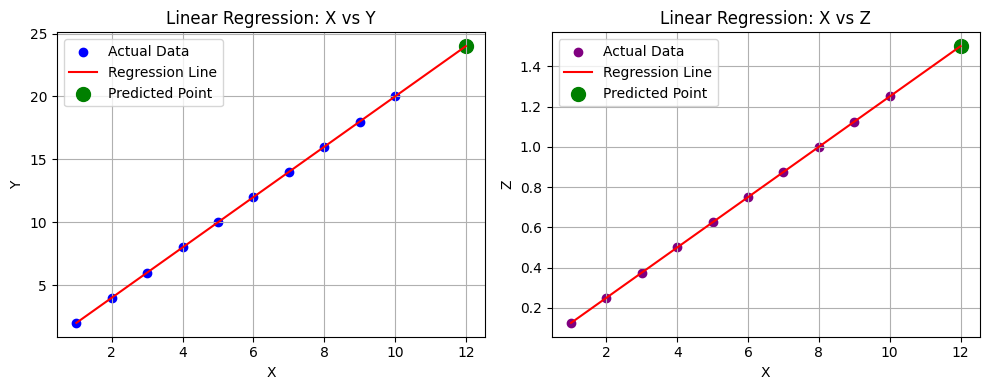

In [7]:
# ----------------------------------
# Plot X vs Y and X vs Z side by side
# ----------------------------------
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.scatter(X, Y, color="blue", label="Actual Data")
plt.plot(x_range, y_pred_line, color="red", label="Regression Line")
plt.scatter(new_x_value, predicted_y, color="green", s=100, label="Predicted Point")
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Linear Regression: X vs Y")
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.scatter(X, Z, color="purple", label="Actual Data")
plt.plot(x_range, z_pred_line, color="red", label="Regression Line")
plt.scatter(new_x_value, predicted_z, color="green", s=100, label="Predicted Point")
plt.xlabel("X")
plt.ylabel("Z")
plt.title("Linear Regression: X vs Z")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

### What each plot shows
- **Blue / purple dots** – original data from the CSV
- **Red line** – the learned regression model
- **Green dot** – the prediction for the new X value

This visually answers: does the data look linear, did the model learn
correctly, and where does the new prediction fall relative to known data?